In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress, pearsonr
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm
from matplotlib.ticker import MaxNLocator, LinearLocator, FormatStrFormatter


plt.rcParams['font.size'] = 7
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42


In [ ]:
ft = pd.read_csv('data/2_preprocessed/ab_rel.csv', index_col=0)
meta_df = pd.read_csv('data/mmi_fit_sepa.tsv', sep='\t').set_index('#SampleID')


meta_df["Group"] = meta_df.apply(
    lambda row: row["Separation"] if row["Host_disease"] == "Control" else row["Host_disease"],
    axis=1
)

meta_control = meta_df[meta_df["Host_disease"] == "Control"]

ft = ft.T

ft_con_ids = set(ft.index)
meta_df_control_ids = set(meta_control.index)

common_control = sorted(ft_con_ids & meta_df_control_ids)


feature_table = ft.loc[common_control]

In [7]:
## short name function
def extract_p_g_or_f(top: str) -> str:
    """
    genus 이름 우선 반환
    genus 없으면 family → order → class → phylum 기준으로
    상위분류 + unclassified genus 반환
    Others는 그대로 유지
    """

    if top == "Others":
        return "Others"

    parts = [x.strip() for x in top.split(";") if x.strip()]

    tax_map = {}
    has_g_rank = False
    for part in parts:
        if "__" in part:
            rank, name = part.split("__", 1)
            tax_map[rank] = name.strip()

            if rank == "g":
                has_g_rank = True

    # 1. genus 있으면 genus name만 반환
    g = tax_map.get("g", "")
    if g:
        return g

    # 2. genus 없으면 상위 rank 탐색
    for rank in ["f", "o", "c", "p"]:
        val = tax_map.get(rank, "")
        if val:
            if has_g_rank:
                return f"{val} unclassified genus"
            else:
                return f"{val} unclassified genus(__)"

    return top

In [8]:
cont = {col: extract_p_g_or_f(col) for col in feature_table.columns}

cont

feature_table_short = feature_table.rename(columns=cont)

In [9]:
def plot_age_abundance_scatter(
    feature_table: pd.DataFrame,
    metadata: pd.DataFrame,
    features,
    age_col: str = "real_year",
    output_dir: str | None = None,
    y_scale: str = "linear",
    pseudocount: float = 1e-6,
    prevalence_threshold: float = 0,
    figsize=(4, 5.5),
    dpi: int = 300,
):
    if isinstance(features, str):
        features = [features]

    common_samples = feature_table.index.intersection(metadata.index)

    if len(common_samples) == 0:
        raise ValueError("No matched sample IDs between feature_table and metadata.")

    ft = feature_table.loc[common_samples].copy()
    meta = metadata.loc[common_samples].copy()

    if age_col not in meta.columns:
        raise ValueError(f"{age_col} is not found in metadata columns.")

    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)

    results = []

    for feature in features:
        if feature not in ft.columns:
            print(f"[Skip] {feature} is not found in feature_table.")
            continue

        abundance = ft[feature]

        if isinstance(abundance, pd.DataFrame):
            abundance = abundance.sum(axis=1)

        df = pd.DataFrame({
            "age": meta[age_col],
            "abundance": abundance
        }).dropna()

        df["age"] = pd.to_numeric(df["age"], errors="coerce")
        df["abundance"] = pd.to_numeric(df["abundance"], errors="coerce")
        df = df.dropna()

        if y_scale == "log":
            df["plot_abundance"] = df["abundance"] + pseudocount
        elif y_scale == "linear":
            df["plot_abundance"] = df["abundance"]
        else:
            raise ValueError("y_scale must be either 'linear' or 'log'.")

        # quadratic regression line + 95% CI
        X = pd.DataFrame({
           "age": df["age"],
        })
        X = sm.add_constant(X)

        model = sm.OLS(df["plot_abundance"], X).fit()

        x_fit = np.linspace(df["age"].min(), df["age"].max(), 200)
        X_fit = sm.add_constant(x_fit)

        pred = model.get_prediction(X_fit)
        y_fit = pred.predicted_mean
        ci_low, ci_high = pred.conf_int().T

        pearson_r, pearson_p = pearsonr(df["age"], df["plot_abundance"])


        fig, ax1 = plt.subplots(figsize=figsize)

        ax1.scatter(
            df["age"],
            df["plot_abundance"],
            alpha=0.5,
            s=30,
            label="Samples"
        )

        ax1.plot(
            x_fit,
            y_fit,
            color="black",
            linewidth=1.5,
            label="Linear fit",
            alpha = 0.5
        )


        if y_scale == "log":
            ax1.set_yscale("log")
        else:
            ax1.set_ylim(0, df["abundance"].quantile(0.98) * 1.1)

        ax1.set_xlabel("Age")
        ax1.set_ylabel("Relative abundance")
        ax1.set_box_aspect(1)
        ax1.set_xticks(range(0,18,4))
        ax1.set_title(feature)
        ax1.xaxis.set_major_locator(LinearLocator(5))
        ax1.xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
        ax1.yaxis.set_major_locator(LinearLocator(5))
        ax1.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
        ax1.grid(True, which="major", alpha=0.3)

        # p-value
        def format_pvalue(p):
            if p < 0.01:
                return "p < 0.01"
            else:
                return f"p = {p:.2f}"
            
        p_text = format_pvalue(model.f_pvalue)

        ax1.text(
            -0.25, 1.3,
            f"Pearson r = {pearson_r:.2f}\n"
            f"$R^2$ = {model.rsquared:.2f}\n"
            f"{p_text}",
            transform=ax1.transAxes,
            va="top",
            ha="left"
        )

        ax1.legend(frameon=False)

        if output_dir is not None:
            safe_name = (
                feature.replace("/", "_")
                       .replace(" ", "_")
                       .replace(";", "_")
                       .replace(":", "_")
                       .replace("(", "")
                       .replace(")", "")
            )
            save_path = os.path.join(output_dir, f"{safe_name}_age_abundance_linear.pdf")
            plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

        plt.show()


        results.append({
            "feature": feature,
            "n_samples": len(df),
            "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj,
            "model_p_value": model.f_pvalue,
            "intercept": model.params["const"],
            "age_coef": model.params["age"],
            "overall_prevalence_percent": (df["abundance"] > prevalence_threshold).mean() * 100
        })

    return pd.DataFrame(results)

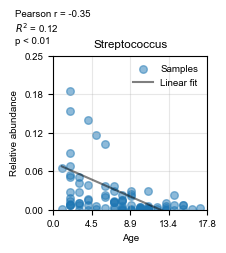

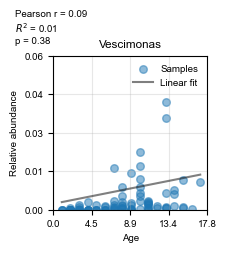

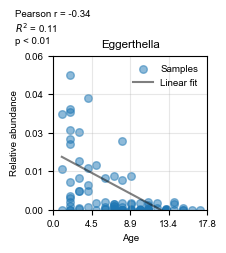

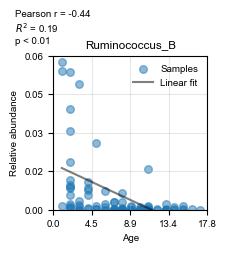

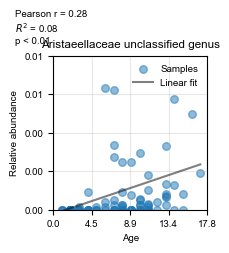

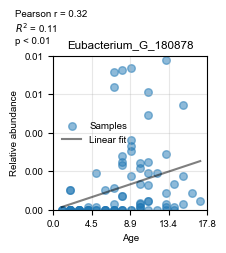

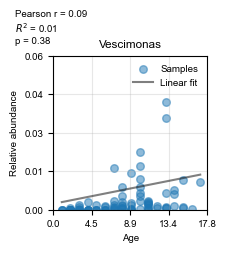

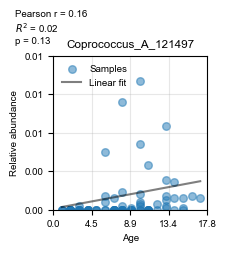

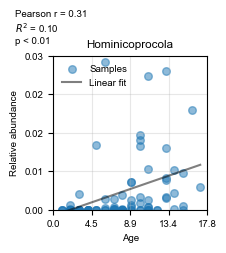

,feature,n_samples,r_squared,adj_r_squared,model_p_value,intercept,age_coef,overall_prevalence_percent
0,Streptococcus,94,0.123278,0.113749,0.000521,0.075184,-0.006064,91.489362
1,Vescimonas,94,0.008418,-0.002360,0.379140,0.002284,0.000664,63.829787
2,Eggerthella,94,0.114950,0.105330,0.000830,0.022171,-0.001787,65.957447
3,Ruminococcus_B,94,0.189490,0.180681,0.000012,0.018052,-0.001590,63.829787
4,Aristaeellaceae unclassified genus,94,0.076062,0.066020,0.007134,-0.000281,0.000187,44.680851
5,Eubacterium_G_180878,94,0.105195,0.095469,0.001427,-0.000011,0.000165,51.063830
6,Vescimonas,94,0.008418,-0.002360,0.379140,0.002284,0.000664,63.829787
7,Coprococcus_A_121497,94,0.024932,0.014333,0.128523,0.000091,0.000133,32.978723
8,Hominicoprocola,94,0.095818,0.085990,0.002398,-0.001222,0.000614,45.744681


In [11]:
features = [
    "Streptococcus",
    "Vescimonas",
    "Eggerthella",
    "Ruminococcus_B",
    "Aristaeellaceae unclassified genus",
    "Eubacterium_G_180878",
    "Vescimonas",
    "Coprococcus_A_121497",
    "Hominicoprocola"
]

result_df = plot_age_abundance_scatter(
    feature_table=feature_table_short,
    metadata=meta_control,
    features=features,
    age_col="real_year",
    output_dir="figure/1_microbiome_age_model/shapley_feature/",
    y_scale="linear",
    figsize=(2, 2)
)

result_df